In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import re
import string


In [ ]:
df = pd.read_csv("flipkart_prod.csv")
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


In [ ]:
df = df.dropna(subset=['Review'])
df['Clean_Review'] = df['Review'].apply(clean_text)

In [ ]:
print("Missing sentiment values:", df['Sentiment'].isnull().sum())

df = df.dropna(subset=['Sentiment'])


Missing sentiment values: 0


In [ ]:
le = LabelEncoder()
df['Sentiment_Encoded'] = le.fit_transform(df['Sentiment'])

print("Classes:", le.classes_)

Classes: ['negative' 'neutral' 'positive']


In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['Clean_Review'])
y = df['Sentiment_Encoded']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**1. Logistic Regression**

In [ ]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log, target_names=le.classes_))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8301827521850804
Precision: 0.9058748409307651
Recall: 0.8301827521850804
F1 Score: 0.8624223063153266

Classification Report:

              precision    recall  f1-score   support

    negative       0.84      0.78      0.81      7218
     neutral       0.14      0.41      0.21      2659
    positive       0.96      0.86      0.91     44240

    accuracy                           0.83     54117
   macro avg       0.65      0.69      0.64     54117
weighted avg       0.91      0.83      0.86     54117



In [ ]:
log_labels = le.inverse_transform(y_pred_log)

print("Prediction Count:")
print(pd.Series(log_labels).value_counts())


Prediction Count:
positive    39637
neutral      7720
negative     6760
Name: count, dtype: int64


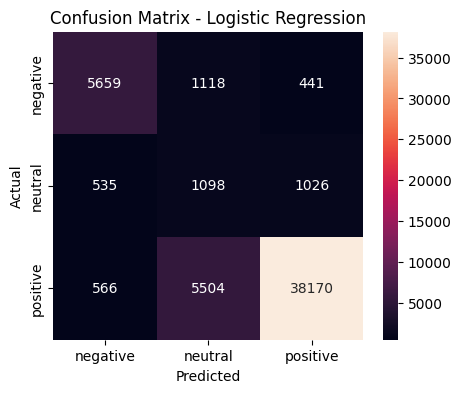

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**2. SVM**

In [ ]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM RESULTS
Accuracy: 0.912910915239204
Precision: 0.8668299327529649
Recall: 0.912910915239204
F1 Score: 0.888691785317483

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.78      0.81      7218
     neutral       0.00      0.00      0.00      2659
    positive       0.92      0.99      0.95     44240

    accuracy                           0.91     54117
   macro avg       0.59      0.59      0.59     54117
weighted avg       0.87      0.91      0.89     54117



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
svm_labels = le.inverse_transform(y_pred_svm)

print("Prediction Count:")
print(pd.Series(svm_labels).value_counts())

Prediction Count:
positive    47490
negative     6627
Name: count, dtype: int64


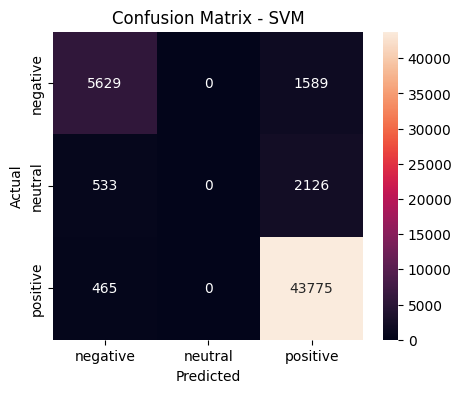

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**3. Naive Bayes**

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("NAIVE BAYES RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nb, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

NAIVE BAYES RESULTS
Accuracy: 0.9078847681874457
Precision: 0.8657755881417514
Recall: 0.9078847681874457
F1 Score: 0.8845718557812163

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.75      0.80      7218
     neutral       0.04      0.00      0.00      2659
    positive       0.92      0.99      0.95     44240

    accuracy                           0.91     54117
   macro avg       0.60      0.58      0.58     54117
weighted avg       0.87      0.91      0.88     54117



In [ ]:
nb_labels = le.inverse_transform(y_pred_nb)

print("Prediction Count:")
print(pd.Series(nb_labels).value_counts())

Prediction Count:
positive    47601
negative     6386
neutral       130
Name: count, dtype: int64


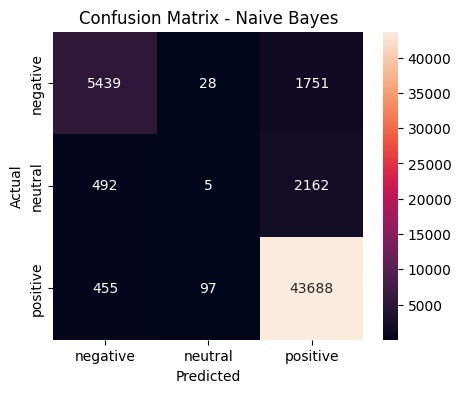

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**4.Random Forest**

In [ ]:
rf_model = RandomForestClassifier(class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

RANDOM FOREST RESULTS
Accuracy: 0.8321969067021453
Precision: 0.9069276767007619
Recall: 0.8321969067021453
F1 Score: 0.864090252845082

Classification Report:

              precision    recall  f1-score   support

    negative       0.85      0.78      0.81      7218
     neutral       0.14      0.41      0.21      2659
    positive       0.96      0.87      0.91     44240

    accuracy                           0.83     54117
   macro avg       0.65      0.69      0.65     54117
weighted avg       0.91      0.83      0.86     54117



In [ ]:
rf_labels = le.inverse_transform(y_pred_rf)

print("Prediction Count:")
print(pd.Series(rf_labels).value_counts())

Prediction Count:
positive    39800
neutral      7671
negative     6646
Name: count, dtype: int64


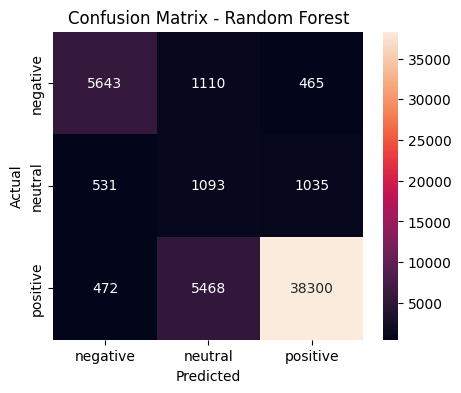

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Accuracy of all Models**
1. Logistic regression - 83
2. SVM - 91
3. Naive Bayes - 91
4. Random Forest - 83